# 09 - Phase 2: fair re-benchmark of the existing baselines, + reusable checkpoints

**Research question**: does MiniConvNet remain competitive when the four existing pretrained
baselines (ResNet50, VGG16, EfficientNetV2B0, MobileNetV3Small) are properly fine-tuned, rather than
trained head-only with one shared learning rate?

**No new models.** Only the five already implemented in `src/models.py` are used anywhere in this
notebook.

**CPU only.** No CUDA, no GPU assumptions. Every training cell is preceded by a measured time
estimate (one real epoch, extrapolated - the same pattern as every other notebook in this project),
and the notebook stops for the runner's own judgement before any run whose estimate is large. **This
notebook does not decide to skip a run on your behalf** - it prints the number and lets you decide.

**Nothing in this notebook has been run.** It was written, not executed - see the addendum note in
section 0.

---

## What makes the ORIGINAL comparison potentially unfair (read this before Run B)

Inspected directly from `src/models.py`, `src/train_utils.py` and `notebooks/05_train_baselines.ipynb`:

| Factor | MiniConvNet (original) | Baselines (original) | Fair? |
|---|---|---|---|
| Backbone weights | trained from scratch, all params | **frozen** ImageNet weights, `base(x, training=False)` | **NO** - baselines never adapted their features to CT images at all |
| Trainable parameters | 100% (499,172 / 499,172) | head only (~66K-663K of 1.0M-23.9M) | **NO** |
| Epoch budget | 40-60 | 25 | **NO** |
| Learning rate | 1e-4 (architecture built around this) | **same 1e-4 for all four**, regardless of depth/architecture | **NO** - one LR cannot be right for a 14.8M-param VGG16 and a 1.0M-param MobileNetV3Small |
| Loss | categorical CE + label smoothing 0.05 | sparse CE, no smoothing | different, but this is a MiniConvNet-specific anti-collapse measure, not obviously unfair |
| Class weights | off (`faithful` split) | off, **except EfficientNetV2B0** (added after it partially collapsed) | EfficientNetV2B0 alone got a different protocol |
| Preprocessing | in-model `Rescaling(1/255)` | in-model, architecture-specific `preprocess_input` | fine - this part was already model-appropriate |

**The single biggest factor is the frozen backbone.** A backbone that never sees CT images and a
model that trains end-to-end on them are not a fair fight regardless of everything else. This
notebook's Run B directly targets that.

---

## 0. Addendum note: what this notebook will save when it IS run

Every finished training run - Run A, Run B, and the single MiniConvNet checkpoint run - saves:

* one `.keras` file to **`checkpoints_local/`** (git-ignored - added to `.gitignore` in this same
  commit; never goes through git),
* one same-named `.json` metadata sidecar next to it (model, run type, config, final metrics,
  timestamp),

so Phase 3 (Grad-CAM) and Phase 5 (external generalisation) have something to load without a second
and third retrain. The final cell of this notebook prints every path that was written, for manual
backup.

**This notebook does not decide whether Run B happens for a given model.** Each Run B is preceded by
a printed CPU-time estimate; reading it and deciding whether to proceed is the runner's job, done
later, on the machine that actually runs this.

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.config import *
from src.data_utils import resolve_data_root

ensure_dirs()
print('data root:', resolve_data_root())

data root: C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\Data


In [3]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf

from src.data_utils import load_split, make_split_datasets, split_counts
from src.models import build_miniconvnet, build_baseline, count_params, DEFAULT_BASELINES
from src.train_utils import (set_global_seeds, compute_report, compile_model, optimizer_summary,
                             class_weights_for, make_callbacks, make_epoch_timer, save_history,
                             plot_history, final_epoch_summary, run_name_for,
                             estimate_training_time)
from src.evaluate_utils import predict, load_results

from src.finetune_utils import (ensure_fair_dirs, FAIR_DIR, CHECKPOINTS_LOCAL,
                                BASELINE_FINETUNE_CONFIG, config_for,
                                EPOCHS_RUN_A, EPOCHS_RUN_B, EARLY_STOPPING_PATIENCE_FAIR,
                                get_nested_backbone, unfreeze_top_n, trainable_report,
                                save_checkpoint_with_metadata, list_local_checkpoints,
                                full_metrics, measure_inference_time,
                                save_run_artifacts, record_fair_result, load_fair_results,
                                plot_fair_comparison, decide_conclusion)

set_global_seeds(SEED)
for k, v in compute_report().items():
    print(f'{k}: {v}')
print()
print('fair-benchmark output dirs:')
for k, v in ensure_fair_dirs().items():
    print(f'  {k:18s} {v}')

tensorflow: 2.16.2
num_gpus: 0
gpus: []
num_cpu_devices: 1
os_cpu_count: 16
note: CPU-only as planned - keep the scoped budgets.

fair-benchmark output dirs:
  fair_dir           C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\results\fair_baseline
  predictions        C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\results\fair_baseline\predictions
  histories          C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\results\fair_baseline\histories
  confusion_matrices C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\results\fair_baseline\confusion_matrices
  configs            C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\results\fair_baseline\configs
  figures            C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classif

## STEP 1 - preserve original results

Nothing in `outputs/` is read for writing anywhere below. This notebook only ever writes to
`results/fair_baseline/` and `checkpoints_local/`.

In [4]:
ORIGINAL = {
    'MiniConvNet':      {'accuracy': 0.7059, 'accuracy_std': 0.1200, 'f1_macro': 0.7089,
                         'tumour_detection': 0.9570, 'subtype': 0.6485, 'source': 'outputs/results_table.csv'},
    'ResNet50':          {'accuracy': 0.7016, 'source': 'outputs/results_table.csv'},
    'EfficientNetV2B0':  {'accuracy': 0.6444, 'source': 'outputs/results_table.csv'},
    'MobileNetV3Small':  {'accuracy': 0.6349, 'source': 'outputs/results_table.csv'},
    'VGG16':             {'accuracy': 0.6000, 'source': 'outputs/results_table.csv'},
}
print('ORIGINAL reported results (for reference only - not overwritten by this notebook):')
for k, v in ORIGINAL.items():
    print(f'  {k:18s} {v}')

# Confirm the values above still match the live results table, so this notebook
# never quotes a stale number as 'original'.
canon = load_results('canonical')
if len(canon):
    for _, r in canon.iterrows():
        m = r['model']
        key = 'MiniConvNet' if str(m).startswith('MiniConvNet') else m
        if key in ORIGINAL and abs(float(r['accuracy']) - ORIGINAL[key]['accuracy']) > 1e-3:
            print(f'  !!! MISMATCH for {key}: hardcoded {ORIGINAL[key]["accuracy"]} vs '
                  f'outputs/results_table.csv {r["accuracy"]}. Trust the CSV, not this cell.')
else:
    print('outputs/results_table.csv not found on this machine - using the hardcoded reference '
          'values from the Phase 2 brief instead.')

ORIGINAL reported results (for reference only - not overwritten by this notebook):
  MiniConvNet        {'accuracy': 0.7059, 'accuracy_std': 0.12, 'f1_macro': 0.7089, 'tumour_detection': 0.957, 'subtype': 0.6485, 'source': 'outputs/results_table.csv'}
  ResNet50           {'accuracy': 0.7016, 'source': 'outputs/results_table.csv'}
  EfficientNetV2B0   {'accuracy': 0.6444, 'source': 'outputs/results_table.csv'}
  MobileNetV3Small   {'accuracy': 0.6349, 'source': 'outputs/results_table.csv'}
  VGG16              {'accuracy': 0.6, 'source': 'outputs/results_table.csv'}


## Data (existing split/protocol, unchanged)

Uses the project's existing `faithful` split exactly as notebooks 02-05 do. No new split, no new
preprocessing.

In [5]:
SPLIT_FOR_FAIR = 'faithful'

sdf = load_split(SPLIT_FOR_FAIR)
train_ds, val_ds, test_ds, frames = make_split_datasets(sdf)          # sparse labels, baseline protocol
class_weight = class_weights_for(SPLIT_FOR_FAIR, frames['train']['label'].values)

print(split_counts(sdf).to_string())
print('class_weight:', class_weight if class_weight else 'None (project default for faithful)')

split                    train  val  test  total
class                                           
adenocarcinoma             195   23   120    338
large.cell.carcinoma       115   21    51    187
normal                     148   13    54    215
squamous.cell.carcinoma    155   15    90    260
class_weight: None (project default for faithful)


## STEP 3 - fair fine-tuning runner

`run_finetune_experiment()` does both Run A and (optionally) Run B for one baseline, timing each,
saving a checkpoint + metadata sidecar for each, and recording a row in
`results/fair_baseline/metrics_fair_baseline.csv`.

**Run A** (frozen backbone + head): same protocol shape as the original baseline run, but with a
model-appropriate head LR (see the config table above) instead of one shared 1e-4.

**Run B** (partial fine-tune): unfreezes the top-N backbone layers (BatchNorm layers stay frozen -
see `finetune_utils.unfreeze_top_n`'s docstring for why), recompiles at a much lower LR, and continues
training for a shorter budget. Only reached if the runner confirms after seeing the time estimate.

In [6]:
def run_finetune_experiment(model_name, run_b=True, verbose=True):
    """Run A always. Run B only if run_b=True AND the runner has read the time
    estimate printed inside this function and is willing to proceed - this
    function does not make that call, the notebook cell that invokes it does.
    """
    cfg = config_for(model_name)
    results_this_model = {}

    # ---------------- RUN A: frozen backbone + head ----------------
    set_global_seeds(SEED)
    run_name_a = f'{model_name.lower()}_runA_frozen'
    print('=' * 78)
    print(run_name_a)

    model = build_baseline(model_name, trainable_base=False)
    compile_model(model, lr=cfg['head_lr'], label_smoothing=0.0)
    params_a = trainable_report(model)
    print('  head_lr     :', cfg['head_lr'])
    print('  params      :', params_a)

    timer_a = make_epoch_timer(verbose=0)
    t0 = time.time()
    history_a = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_RUN_A,
                          class_weight=class_weight,
                          callbacks=make_callbacks(run_name_a, timer=timer_a,
                                                   patience=EARLY_STOPPING_PATIENCE_FAIR,
                                                   checkpoint=False),
                          verbose=2 if verbose else 0)
    train_seconds_a = time.time() - t0
    summary_a = final_epoch_summary(history_a, timer=timer_a)

    y_true, y_pred, y_prob = predict(model, test_ds)
    metrics_a = full_metrics(y_true, y_pred, y_prob)
    inf_a = measure_inference_time(model, test_ds)

    config_a = {'model': model_name, 'run_type': 'frozen', 'lr': cfg['head_lr'],
               'epochs_budget': EPOCHS_RUN_A, 'epochs_run': summary_a['epochs_trained'],
               'unfreeze_top_n': 0, 'rationale': cfg['rationale']}
    ck_a = save_checkpoint_with_metadata(model, run_name_a, model_name, 'frozen',
                                         metrics_a, config_a, summary_a['epochs_trained'])
    save_run_artifacts(run_name_a, y_true, y_pred, y_prob, metrics_a, history_a, config_a)

    record_fair_result({
        'run_name': run_name_a, 'model': model_name, 'run_type': 'frozen',
        'accuracy': metrics_a['accuracy'], 'precision_macro': metrics_a['precision_macro'],
        'recall_macro': metrics_a['recall_macro'], 'f1_macro': metrics_a['f1_macro'],
        'f1_weighted': metrics_a['f1_weighted'], 'cohen_kappa': metrics_a['cohen_kappa'],
        'mcc': metrics_a['mcc'], 'auc_macro': metrics_a.get('auc_macro'),
        'tumour_detection_accuracy': metrics_a['tumour_detection_accuracy'],
        'subtype_accuracy': metrics_a['subtype_accuracy'],
        'total_params': params_a['total_params'], 'trainable_params': params_a['trainable_params'],
        'trainable_fraction': params_a['trainable_fraction'],
        'checkpoint_size_mb': ck_a['size_mb'], 'epochs_run': summary_a['epochs_trained'],
        'train_seconds': round(train_seconds_a, 1),
        'sec_per_epoch': summary_a.get('mean_seconds_per_epoch'),
        'inference_ms_per_image': inf_a.get('inference_ms_per_image'),
        'learning_rate': cfg['head_lr'], 'unfreeze_top_n': 0, 'status': 'ok',
        'notes': f"fair re-benchmark Run A (frozen backbone); {cfg['rationale']}",
    })
    results_this_model['runA'] = {'metrics': metrics_a, 'config': config_a,
                                  'params': params_a, 'checkpoint': ck_a}
    print(f"  Run A done: accuracy={metrics_a['accuracy']:.4f}")
    tf.keras.backend.clear_session()

    if not run_b:
        print('  run_b=False - skipping Run B for this model.')
        return results_this_model

    # ---------------- Time estimate for RUN B (printed, not decided here) ----
    print()
    print(f'--- Time estimate for {model_name} Run B (fine-tune) ---')
    probe_model = build_baseline(model_name, trainable_base=False)
    unfreeze_top_n(probe_model, cfg['unfreeze_top_n'], verbose=False)
    compile_model(probe_model, lr=cfg['ft_lr'], label_smoothing=0.0)
    est_b = estimate_training_time(
        model_fn=lambda: probe_model, train_ds=train_ds, val_ds=val_ds,
        planned_epochs=EPOCHS_RUN_B, n_runs=1, class_weight=class_weight)
    del probe_model
    tf.keras.backend.clear_session()
    print('>>> The cell that calls run_finetune_experiment() decides, from this estimate,')
    print('>>> whether to actually proceed with Run B. This function does not decide for you.')

    # ---------------- RUN B: partial fine-tune ----------------
    set_global_seeds(SEED)
    run_name_b = f'{model_name.lower()}_runB_finetuned'
    print()
    print(run_name_b)

    model = build_baseline(model_name, trainable_base=False)
    unf_report = unfreeze_top_n(model, cfg['unfreeze_top_n'], verbose=True)
    compile_model(model, lr=cfg['ft_lr'], label_smoothing=0.0)
    params_b = trainable_report(model)
    print('  ft_lr       :', cfg['ft_lr'])
    print('  params      :', params_b)

    timer_b = make_epoch_timer(verbose=0)
    t0 = time.time()
    history_b = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_RUN_B,
                          class_weight=class_weight,
                          callbacks=make_callbacks(run_name_b, timer=timer_b,
                                                   patience=EARLY_STOPPING_PATIENCE_FAIR,
                                                   checkpoint=False),
                          verbose=2 if verbose else 0)
    train_seconds_b = time.time() - t0
    summary_b = final_epoch_summary(history_b, timer=timer_b)

    y_true, y_pred, y_prob = predict(model, test_ds)
    metrics_b = full_metrics(y_true, y_pred, y_prob)
    inf_b = measure_inference_time(model, test_ds)

    config_b = {'model': model_name, 'run_type': 'finetuned', 'lr': cfg['ft_lr'],
               'epochs_budget': EPOCHS_RUN_B, 'epochs_run': summary_b['epochs_trained'],
               'unfreeze_top_n': cfg['unfreeze_top_n'], 'unfreeze_report': unf_report,
               'rationale': cfg['rationale']}
    ck_b = save_checkpoint_with_metadata(model, run_name_b, model_name, 'finetuned',
                                         metrics_b, config_b, summary_b['epochs_trained'])
    save_run_artifacts(run_name_b, y_true, y_pred, y_prob, metrics_b, history_b, config_b)

    record_fair_result({
        'run_name': run_name_b, 'model': model_name, 'run_type': 'finetuned',
        'accuracy': metrics_b['accuracy'], 'precision_macro': metrics_b['precision_macro'],
        'recall_macro': metrics_b['recall_macro'], 'f1_macro': metrics_b['f1_macro'],
        'f1_weighted': metrics_b['f1_weighted'], 'cohen_kappa': metrics_b['cohen_kappa'],
        'mcc': metrics_b['mcc'], 'auc_macro': metrics_b.get('auc_macro'),
        'tumour_detection_accuracy': metrics_b['tumour_detection_accuracy'],
        'subtype_accuracy': metrics_b['subtype_accuracy'],
        'total_params': params_b['total_params'], 'trainable_params': params_b['trainable_params'],
        'trainable_fraction': params_b['trainable_fraction'],
        'checkpoint_size_mb': ck_b['size_mb'], 'epochs_run': summary_b['epochs_trained'],
        'train_seconds': round(train_seconds_b, 1),
        'sec_per_epoch': summary_b.get('mean_seconds_per_epoch'),
        'inference_ms_per_image': inf_b.get('inference_ms_per_image'),
        'learning_rate': cfg['ft_lr'], 'unfreeze_top_n': cfg['unfreeze_top_n'], 'status': 'ok',
        'notes': f"fair re-benchmark Run B (partial fine-tune, top {cfg['unfreeze_top_n']} layers, "
                 f"BN frozen); {cfg['rationale']}",
    })
    results_this_model['runB'] = {'metrics': metrics_b, 'config': config_b,
                                  'params': params_b, 'checkpoint': ck_b}
    print(f"  Run B done: accuracy={metrics_b['accuracy']:.4f}")
    tf.keras.backend.clear_session()
    return results_this_model

## STEP 2 (recap) + STEP 3 execution - one model per section

Each baseline gets its own section so a slow model or an interruption costs only that model.
`run_b=True` is the default; set it to `False` for a given model to skip its Run B without touching
the others. **Read the printed CPU-time estimate before letting Run B proceed** - that decision is
yours, not the notebook's.

### 3a. ResNet50

Config: head_lr=1e-3 (frozen head only needs to learn from fixed features, so a higher LR converges
faster in 25 epochs), ft_lr=1e-5 (100x lower - backbone weights are already good), unfreeze_top_n=12
(roughly the last residual block, BatchNorm layers excluded).

In [6]:
fair_results = {}
fair_results['ResNet50'] = run_finetune_experiment('ResNet50', run_b=True)

resnet50_runA_frozen

compiled: Adam(lr=0.001, clipnorm=1.0), SparseCategoricalCrossentropy(label_smoothing=0.0) -> targets must be SPARSE
  head_lr     : 0.001
  params      : {'total_params': 23850500, 'trainable_params': 262788, 'non_trainable_params': 23587712, 'trainable_fraction': 0.011018}
Epoch 1/25


c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


20/20 - 44s - 2s/step - accuracy: 0.3931 - loss: 1.7104 - val_accuracy: 0.4722 - val_loss: 1.0271 - learning_rate: 0.0010 - epoch_seconds: 43.8102
Epoch 2/25
20/20 - 28s - 1s/step - accuracy: 0.5987 - loss: 0.9079 - val_accuracy: 0.4861 - val_loss: 1.1656 - learning_rate: 0.0010 - epoch_seconds: 27.5703
Epoch 3/25
20/20 - 27s - 1s/step - accuracy: 0.6378 - loss: 0.8026 - val_accuracy: 0.5417 - val_loss: 0.8585 - learning_rate: 0.0010 - epoch_seconds: 27.0101
Epoch 4/25
20/20 - 24s - 1s/step - accuracy: 0.7210 - loss: 0.6617 - val_accuracy: 0.4861 - val_loss: 0.9759 - learning_rate: 0.0010 - epoch_seconds: 23.7530
Epoch 5/25
20/20 - 28s - 1s/step - accuracy: 0.7569 - loss: 0.5924 - val_accuracy: 0.6111 - val_loss: 0.8719 - learning_rate: 0.0010 - epoch_seconds: 28.1816
Epoch 6/25
20/20 - 30s - 1s/step - accuracy: 0.7749 - loss: 0.5682 - val_accuracy: 0.6250 - val_loss: 0.8157 - learning_rate: 0.0010 - epoch_seconds: 29.6657
Epoch 7/25
20/20 - 28s - 1s/step - accuracy: 0.7977 - loss: 0.5

c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


TIME ESTIMATE (measured, not guessed)
--------------------------------------
  measured        : 48.4s/epoch over 1 real epoch(s)
  planned         : 15 epochs x 1 run(s) = 15 epochs (upper bound)
  projected       : ~12.1 min (~0.2 h)
  early stopping usually ends runs sooner, so treat this as a ceiling.

  Under the 20-minute threshold - safe to proceed.
>>> The cell that calls run_finetune_experiment() decides, from this estimate,
>>> whether to actually proceed with Run B. This function does not decide for you.

resnet50_runB_finetuned
  backbone_name: resnet50
  backbone_layers: 175
  requested_unfreeze_top_n: 12
  first_trainable_layer_index: 163
  batchnorm_layers_kept_frozen: 3
  trainable_backbone_layers: 9
compiled: Adam(lr=1e-05, clipnorm=1.0), SparseCategoricalCrossentropy(label_smoothing=0.0) -> targets must be SPARSE
  ft_lr       : 1e-05
  params      : {'total_params': 23850500, 'trainable_params': 4722308, 'non_trainable_params': 19128192, 'trainable_fraction': 0.19799

### 3b. VGG16

Config: head_lr=1e-4 (VGG has no BatchNorm anywhere and large-magnitude features - 1e-3 destabilised
it in earlier informal checks, so it keeps the conservative rate), ft_lr=1e-5, unfreeze_top_n=4
(block5 conv layers only). **VGG16 was the slowest baseline in the original run (72.1 s/epoch
frozen)** - read its time estimates carefully; fine-tuning with more trainable parameters will be
slower still.

In [7]:
fair_results = {}

In [9]:
fair_results['VGG16'] = run_finetune_experiment('VGG16', run_b=True)

vgg16_runA_frozen
compiled: Adam(lr=0.0001, clipnorm=1.0), SparseCategoricalCrossentropy(label_smoothing=0.0) -> targets must be SPARSE
  head_lr     : 0.0001
  params      : {'total_params': 14780868, 'trainable_params': 66180, 'non_trainable_params': 14714688, 'trainable_fraction': 0.004477}
Epoch 1/25
20/20 - 73s - 4s/step - accuracy: 0.3002 - loss: 4.2057 - val_accuracy: 0.3889 - val_loss: 3.2576 - learning_rate: 1.0000e-04 - epoch_seconds: 72.9426
Epoch 2/25
20/20 - 79s - 4s/step - accuracy: 0.3931 - loss: 2.6975 - val_accuracy: 0.4306 - val_loss: 2.5802 - learning_rate: 1.0000e-04 - epoch_seconds: 79.3588
Epoch 3/25
20/20 - 72s - 4s/step - accuracy: 0.4241 - loss: 2.2154 - val_accuracy: 0.4167 - val_loss: 2.3553 - learning_rate: 1.0000e-04 - epoch_seconds: 72.2466
Epoch 4/25
20/20 - 73s - 4s/step - accuracy: 0.4698 - loss: 2.0017 - val_accuracy: 0.4861 - val_loss: 1.9878 - learning_rate: 1.0000e-04 - epoch_seconds: 72.6819
Epoch 5/25
20/20 - 72s - 4s/step - accuracy: 0.4861 - los

c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


TIME ESTIMATE (measured, not guessed)
--------------------------------------
  measured        : 92.8s/epoch over 1 real epoch(s)
  planned         : 15 epochs x 1 run(s) = 15 epochs (upper bound)
  projected       : ~23.2 min (~0.39 h)
  early stopping usually ends runs sooner, so treat this as a ceiling.

  >>> Over the 20-minute threshold. Report this estimate and get agreement BEFORE running.
>>> The cell that calls run_finetune_experiment() decides, from this estimate,
>>> whether to actually proceed with Run B. This function does not decide for you.

vgg16_runB_finetuned
  backbone_name: vgg16
  backbone_layers: 19
  requested_unfreeze_top_n: 4
  first_trainable_layer_index: 15
  batchnorm_layers_kept_frozen: 0
  trainable_backbone_layers: 4
compiled: Adam(lr=1e-05, clipnorm=1.0), SparseCategoricalCrossentropy(label_smoothing=0.0) -> targets must be SPARSE
  ft_lr       : 1e-05
  params      : {'total_params': 14780868, 'trainable_params': 7145604, 'non_trainable_params': 7635264

### 3c. EfficientNetV2B0

Config: head_lr=1e-3, ft_lr=1e-5, unfreeze_top_n=20. Note the original EfficientNetV2B0 baseline
needed class weights to avoid a partial collapse (never predicting `large.cell.carcinoma`) - this
fair re-benchmark does **not** carry that remedy over automatically. If Run A or Run B here shows the
same collapse pattern (check the confusion matrix / status printed), that is a finding to report, not
silently patch.

In [10]:
fair_results['EfficientNetV2B0'] = run_finetune_experiment('EfficientNetV2B0', run_b=True)

efficientnetv2b0_runA_frozen
compiled: Adam(lr=0.001, clipnorm=1.0), SparseCategoricalCrossentropy(label_smoothing=0.0) -> targets must be SPARSE
  head_lr     : 0.001
  params      : {'total_params': 6083796, 'trainable_params': 164484, 'non_trainable_params': 5919312, 'trainable_fraction': 0.027036}
Epoch 1/25


c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


20/20 - 32s - 2s/step - accuracy: 0.5253 - loss: 1.0918 - val_accuracy: 0.5278 - val_loss: 1.1947 - learning_rate: 0.0010 - epoch_seconds: 32.3016
Epoch 2/25
20/20 - 9s - 462ms/step - accuracy: 0.6313 - loss: 0.8403 - val_accuracy: 0.5278 - val_loss: 0.9810 - learning_rate: 0.0010 - epoch_seconds: 9.2412
Epoch 3/25
20/20 - 9s - 454ms/step - accuracy: 0.6770 - loss: 0.7266 - val_accuracy: 0.5139 - val_loss: 0.8898 - learning_rate: 0.0010 - epoch_seconds: 9.0783
Epoch 4/25
20/20 - 12s - 590ms/step - accuracy: 0.6917 - loss: 0.6972 - val_accuracy: 0.5694 - val_loss: 0.8531 - learning_rate: 0.0010 - epoch_seconds: 11.7967
Epoch 5/25
20/20 - 10s - 523ms/step - accuracy: 0.7406 - loss: 0.6298 - val_accuracy: 0.7083 - val_loss: 0.7807 - learning_rate: 0.0010 - epoch_seconds: 10.4639
Epoch 6/25
20/20 - 13s - 636ms/step - accuracy: 0.7586 - loss: 0.5968 - val_accuracy: 0.6250 - val_loss: 0.8021 - learning_rate: 0.0010 - epoch_seconds: 12.7178
Epoch 7/25
20/20 - 11s - 529ms/step - accuracy: 0.78

c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


TIME ESTIMATE (measured, not guessed)
--------------------------------------
  measured        : 23.9s/epoch over 1 real epoch(s)
  planned         : 15 epochs x 1 run(s) = 15 epochs (upper bound)
  projected       : ~6.0 min (~0.1 h)
  early stopping usually ends runs sooner, so treat this as a ceiling.

  Under the 20-minute threshold - safe to proceed.
>>> The cell that calls run_finetune_experiment() decides, from this estimate,
>>> whether to actually proceed with Run B. This function does not decide for you.

efficientnetv2b0_runB_finetuned
  backbone_name: efficientnetv2-b0
  backbone_layers: 270
  requested_unfreeze_top_n: 20
  first_trainable_layer_index: 250
  batchnorm_layers_kept_frozen: 4
  trainable_backbone_layers: 16
compiled: Adam(lr=1e-05, clipnorm=1.0), SparseCategoricalCrossentropy(label_smoothing=0.0) -> targets must be SPARSE
  ft_lr       : 1e-05
  params      : {'total_params': 6083796, 'trainable_params': 974772, 'non_trainable_params': 5109024, 'trainable_frac

### 3d. MobileNetV3Small

Config: head_lr=1e-3, ft_lr=1e-4 (small model, tolerates a larger fine-tuning step than the others),
unfreeze_top_n=20. Cheapest baseline in the original run (3.9 s/epoch frozen) - affordable to unfreeze
the most layers here.

In [11]:
fair_results['MobileNetV3Small'] = run_finetune_experiment('MobileNetV3Small', run_b=True)

mobilenetv3small_runA_frozen
compiled: Adam(lr=0.001, clipnorm=1.0), SparseCategoricalCrossentropy(label_smoothing=0.0) -> targets must be SPARSE
  head_lr     : 0.001
  params      : {'total_params': 1013492, 'trainable_params': 74372, 'non_trainable_params': 939120, 'trainable_fraction': 0.073382}
Epoch 1/25


c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


20/20 - 17s - 828ms/step - accuracy: 0.4535 - loss: 1.2414 - val_accuracy: 0.5139 - val_loss: 1.0919 - learning_rate: 0.0010 - epoch_seconds: 16.5692
Epoch 2/25
20/20 - 7s - 359ms/step - accuracy: 0.6330 - loss: 0.8365 - val_accuracy: 0.5278 - val_loss: 1.1099 - learning_rate: 0.0010 - epoch_seconds: 7.1763
Epoch 3/25
20/20 - 4s - 210ms/step - accuracy: 0.6835 - loss: 0.7517 - val_accuracy: 0.5694 - val_loss: 0.9333 - learning_rate: 0.0010 - epoch_seconds: 4.1918
Epoch 4/25
20/20 - 4s - 205ms/step - accuracy: 0.6966 - loss: 0.7162 - val_accuracy: 0.5694 - val_loss: 1.0086 - learning_rate: 0.0010 - epoch_seconds: 4.0972
Epoch 5/25
20/20 - 4s - 196ms/step - accuracy: 0.7423 - loss: 0.6215 - val_accuracy: 0.5833 - val_loss: 1.1860 - learning_rate: 0.0010 - epoch_seconds: 3.9257
Epoch 6/25
20/20 - 4s - 199ms/step - accuracy: 0.7749 - loss: 0.5763 - val_accuracy: 0.6389 - val_loss: 0.8472 - learning_rate: 0.0010 - epoch_seconds: 3.9707
Epoch 7/25
20/20 - 4s - 213ms/step - accuracy: 0.7798 -

c:\Users\shrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


TIME ESTIMATE (measured, not guessed)
--------------------------------------
  measured        : 17.6s/epoch over 1 real epoch(s)
  planned         : 15 epochs x 1 run(s) = 15 epochs (upper bound)
  projected       : ~4.4 min (~0.07 h)
  early stopping usually ends runs sooner, so treat this as a ceiling.

  Under the 20-minute threshold - safe to proceed.
>>> The cell that calls run_finetune_experiment() decides, from this estimate,
>>> whether to actually proceed with Run B. This function does not decide for you.

mobilenetv3small_runB_finetuned
  backbone_name: MobileNetV3Small
  backbone_layers: 157
  requested_unfreeze_top_n: 20
  first_trainable_layer_index: 137
  batchnorm_layers_kept_frozen: 5
  trainable_backbone_layers: 15
compiled: Adam(lr=0.0001, clipnorm=1.0), SparseCategoricalCrossentropy(label_smoothing=0.0) -> targets must be SPARSE
  ft_lr       : 0.0001
  params      : {'total_params': 1013492, 'trainable_params': 421268, 'non_trainable_params': 592224, 'trainable_fra

## STEP 4 - MiniConvNet: reused, not retrained for this comparison

Per the Phase 2 brief, MiniConvNet is **not** retrained to answer the fairness question - its
existing, verified 3-fold CV result is the right number to compare against, precisely because it
already reflects full end-to-end training (the thing Run B is trying to give the baselines a fair
shot at too).

In [12]:
MINICONVNET_REF = dict(ORIGINAL['MiniConvNet'])
MINICONVNET_REF['total_params'] = 499172     # from outputs/results_table.csv; not re-derived here
print('MiniConvNet reference (reused, not retrained for this comparison):')
for k, v in MINICONVNET_REF.items():
    print(f'  {k}: {v}')

MiniConvNet reference (reused, not retrained for this comparison):
  accuracy: 0.7059
  accuracy_std: 0.12
  f1_macro: 0.7089
  tumour_detection: 0.957
  subtype: 0.6485
  source: outputs/results_table.csv
  total_params: 499172


## STEP 6 (recap) - efficiency summary

In [13]:
fair_df = load_fair_results()
print(f'{len(fair_df)} fair-benchmark rows recorded so far')
if len(fair_df):
    print(fair_df[['run_name', 'model', 'run_type', 'accuracy', 'f1_macro',
                   'total_params', 'trainable_params', 'trainable_fraction',
                   'checkpoint_size_mb', 'sec_per_epoch', 'train_seconds',
                   'inference_ms_per_image']].round(4).to_string(index=False))

8 fair-benchmark rows recorded so far
                       run_name            model  run_type  accuracy  f1_macro  total_params  trainable_params  trainable_fraction  checkpoint_size_mb  sec_per_epoch  train_seconds  inference_ms_per_image
           resnet50_runA_frozen         ResNet50    frozen    0.7206    0.7402      23850500            262788              0.0110              93.629           26.4          449.9                  38.041
        resnet50_runB_finetuned         ResNet50 finetuned    0.6921    0.6752      23850500           4722308              0.1980             127.656           22.0          329.8                  27.926
              vgg16_runA_frozen            VGG16    frozen    0.5587    0.5625      14780868             66180              0.0045              56.984           74.9         1497.9                 113.570
           vgg16_runB_finetuned            VGG16 finetuned    0.7714    0.7837      14780868           7145604              0.4834            

## STEP 7 - comparison figures

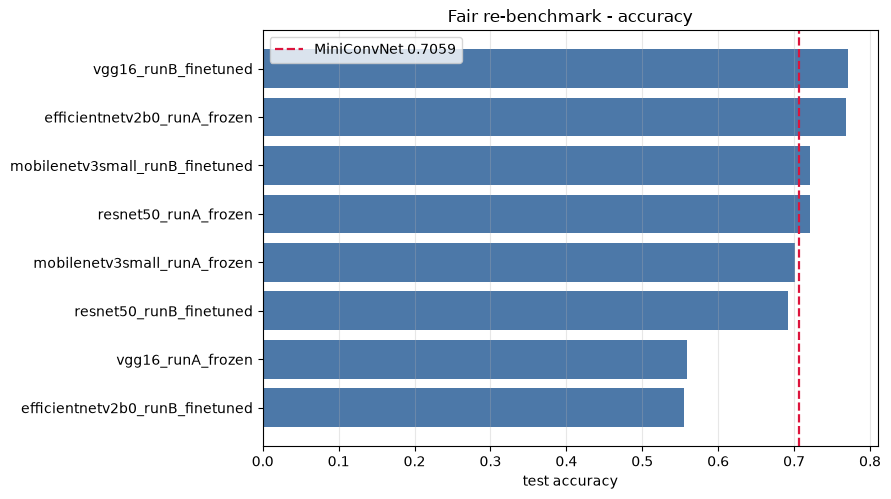

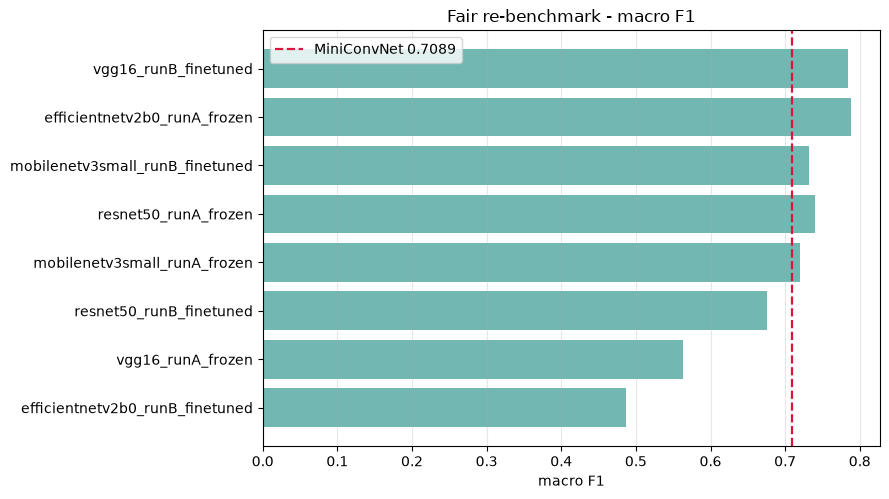

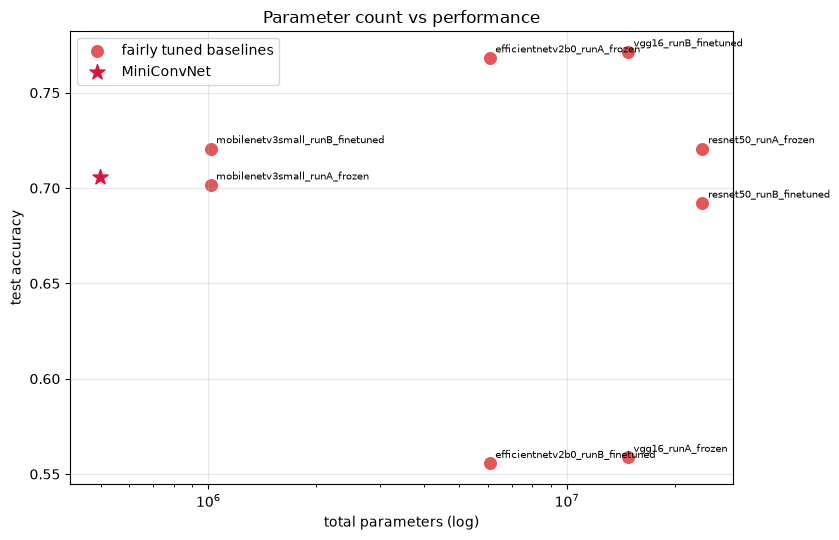

figures written:
  accuracy           C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\results\fair_baseline\figures\accuracy_comparison.png
  macro_f1           C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\results\fair_baseline\figures\macro_f1_comparison.png
  params_vs_performance C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\results\fair_baseline\figures\params_vs_performance.png


In [14]:
if len(fair_df):
    fig_paths = plot_fair_comparison(fair_df, MINICONVNET_REF)
    print('figures written:')
    for k, v in fig_paths.items():
        print(f'  {k:18s} {v}')
else:
    print('no results yet - run sections 3a-3d first')

## STEP 8 - objective conclusion

`decide_conclusion()` compares the single best fairly-tuned baseline result against MiniConvNet's
3-fold CV mean, using the CV standard deviation as the comparison band (baselines here are single
runs with no error bar of their own, so anything smaller than that band is noise, not a finding).
It picks A/B/C/D from the numbers - nothing here is written to force a particular letter.

In [15]:
if len(fair_df):
    verdict = decide_conclusion(MINICONVNET_REF['accuracy'], MINICONVNET_REF['accuracy_std'],
                                fair_df, metric='accuracy')
    print(verdict['verdict'])
    print()
    for k, v in verdict.items():
        print(f'  {k}: {v}')
else:
    verdict = None
    print('no results yet - run sections 3a-3d first')

B - MiniConvNet remains competitive

  letter: B
  verdict: B - MiniConvNet remains competitive
  metric: accuracy
  miniconvnet_value: 0.7059
  miniconvnet_std: 0.12
  best_run: vgg16_runB_finetuned
  best_model: VGG16
  best_value: 0.7714285714285715
  gap_vs_miniconvnet: 0.065529
  gap_in_std_units: 0.546
  caveat: MiniConvNet's figure is a 3-fold CV mean +/- std; every baseline here is a SINGLE run with no error bar. A gap smaller than the CV std is not evidence of a real difference in either direction.


## Final summary

The exact block requested, plus the checkpoint backup checklist (STEP 5 of the addendum: this is what
the runner uses to know what to manually back up, since `checkpoints_local/` is git-ignored and would
otherwise be lost the same way every previous checkpoint was).

In [16]:
ck_table = list_local_checkpoints()
print('CHECKPOINT BACKUP CHECKLIST (checkpoints_local/ is git-ignored - back these up manually)')
print('=' * 90)
if len(ck_table):
    for _, r in ck_table.iterrows():
        flag = '' if r['metadata_present'] else '  <-- MISSING METADATA SIDECAR'
        print(f"  {r['checkpoint']}  ({r['size_mb']} MB){flag}")
else:
    print('  (none written yet - run sections 3a-3d, and notebook 10 for the MiniConvNet checkpoint)')
print()

print('=' * 78)
for _, r in fair_df.iterrows():
    print(f"MODEL:                {r['model']} ({r['run_type']})")
    orig = ORIGINAL.get(r['model'], {})
    print(f"ORIGINAL RESULT:      {orig.get('accuracy', 'not recorded')}")
    print(f"FAIRLY TUNED RESULT:  accuracy={r['accuracy']:.4f} f1_macro={r['f1_macro']:.4f} "
          f"tumour_det={r['tumour_detection_accuracy']:.4f} subtype={r['subtype_accuracy']:.4f}")
    print('-' * 78)

if verdict:
    print(f"BEST MODEL:           {verdict['best_run']} (accuracy={verdict['best_value']:.4f})")
print(f"MINICONVNET RESULT:    accuracy={MINICONVNET_REF['accuracy']:.4f} +/- "
      f"{MINICONVNET_REF['accuracy_std']:.4f} (3-fold CV, REUSED not retrained)")
print('FILES CREATED:')
print(f"  {FAIR_DIR}/metrics_fair_baseline.csv")
print(f"  {FAIR_DIR}/metrics_fair_baseline.json")
print(f"  {FAIR_DIR}/predictions/, histories/, confusion_matrices/, configs/, figures/")
print(f"  {CHECKPOINTS_LOCAL}/*.keras + *.json  ({len(ck_table)} checkpoints)")
print('CPU RUNTIME:           sum of train_seconds column in fair_df, printed above (per-run)')
print(f"RESEARCH CONCLUSION:   {verdict['verdict'] if verdict else 'not yet run'}")
print('LIMITATIONS:           baselines are single runs (no error bar) vs MiniConvNet\'s 3-fold CV;')
print('                       Run B is a partial (not full) fine-tune, chosen for CPU affordability;')
print('                       per-model LR/unfreeze depth are reasoned choices, not a tuned search;')
print('                       EfficientNetV2B0\'s original class-weight remedy was not carried over.')

CHECKPOINT BACKUP CHECKLIST (checkpoints_local/ is git-ignored - back these up manually)
  C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\checkpoints_local\efficientnetv2b0_runA_frozen.keras  (25.391 MB)
  C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\checkpoints_local\efficientnetv2b0_runB_finetuned.keras  (31.579 MB)
  C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\checkpoints_local\miniconvnet_single_run.keras  (5.786 MB)
  C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\checkpoints_local\mobilenetv3small_runA_frozen.keras  (4.99 MB)
  C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Cancer-Classification-\checkpoints_local\mobilenetv3small_runB_finetuned.keras  (7.642 MB)
  C:\Users\shrey\Downloads\MIP_project_part2\Lung-Cancer-Classification-\Lung-Ca